# Analytical Power Analysis

## Setup

In [ ]:

library(here)


here() starts at E:/Github/cfa-power

This is lavaan 0.6-21
lavaan is FREE software! Please report any bugs.

###############################################################################

This is semTools 0.5-8

All users of R (or SEM) are invited to submit functions or ideas for functions.

...


Attaching package: 'dplyr'

The following object is masked from 'package:MASS':

    select

The following objects are masked from 'package:stats':

    filter, lag

The following objects are masked from 'package:base':

    intersect, setdiff, setequal, union

Loading required package: SparseM

## Computing model degrees of freedom

Before any analytical power calculation can be performed, the model degrees of freedom ($df$) must be established. This quantity is the difference between the number of unique variances and covariances in the observed data and the number of freely estimated parameters. It enters the non-central $\chi^2$ distribution directly and is therefore required for both the a priori and the power-curve analyses that follow ([Jak et al., 2021](#ref-jak2021); [Moshagen & Bader, 2024](#ref-moshagen2024)).

In [ ]:

# Compute df for standardized latent variables (std.lv = TRUE)
# 24 observed variables: p*(p+1)/2 = 300 non-redundant sample moments
# analyzemodel: 24 loadings + 6 factor correlations + 1 residual covariance (Q3~~Q4) + 24 residual variances = 55 free parameters
# Model degrees of freedom: df = 300 - 55 = 245
df_model <- 245

cat("Model degrees of freedom (with std.lv = TRUE):", df_model, "\n")


Model degrees of freedom (with std.lv = TRUE): 245 

## A priori power analysis: Determine N

### Model-free approach (RMSEA-based)

The model-free strategy determines the required sample size from four ingredients — the target RMSEA, the significance level, the desired power, and the model degrees of freedom — without requiring an explicitly specified population model ([Jak et al., 2021](#ref-jak2021); [MacCallum et al., 1996](#ref-maccallum1996)). Because RMSEA expresses misfit per degree of freedom, it translates directly into the noncentrality parameter $\lambda = (N-1)\,df\,\text{RMSEA}^2$, which locates the alternative $\chi^2$ distribution relative to the null ([MacCallum et al., 1996](#ref-maccallum1996)).

The output below returns the minimum $N$ needed to detect $\text{RMSEA} = 0.05$ under the chosen $\alpha$ and power, together with equivalent representations of the same effect in terms of $F_0$, $Mc$, $GFI$, and $AGFI$ ([Moshagen & Bader, 2024](#ref-moshagen2024)).


 semPower: A priori power analysis
                                   
 F0                        0.612500
 RMSEA                     0.050000
 Mc                        0.736203
 GFI                       0.951437
 AGFI                      0.940535
                                   
 df                        245     
 Required Num Observations 100     
                                   
 Critical Chi-Square       282.5114
 NCP                       60.63750
 Alpha                     0.050000
 Beta                      0.198392
 Power (1 - Beta)          0.801608
 Implied Alpha/Beta Ratio  0.252026

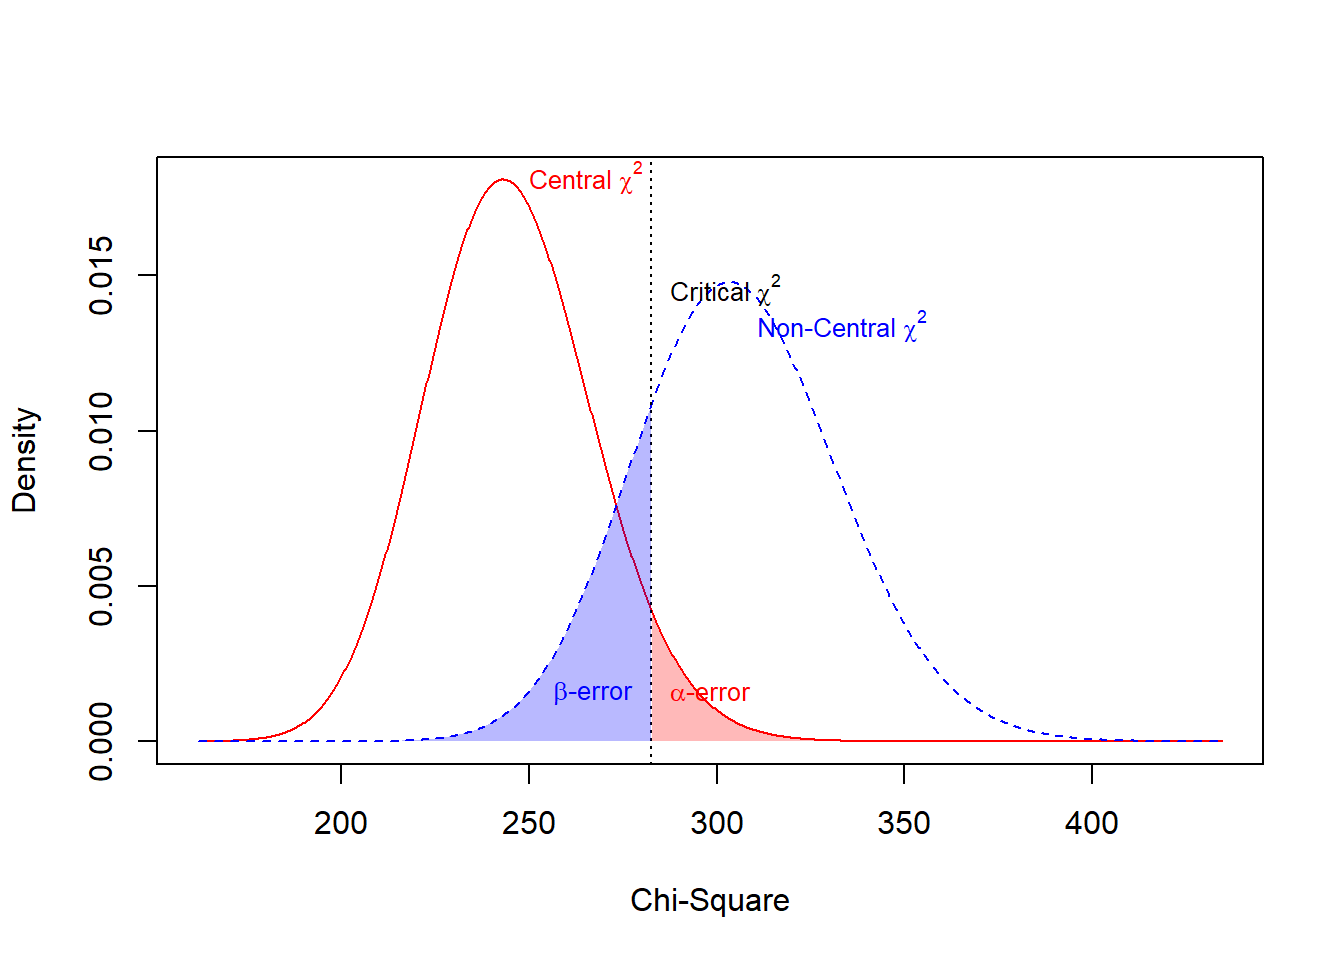

In [ ]:

# Analytical a priori power analysis for the global chi-square test.
# The goal is to determine the minimum N required to detect
# a population misfit corresponding to RMSEA = 0.05.

ap_rmsea <- semPower::semPower.aPriori(
  effect         = 0.05,      # RMSEA under H1
  effect.measure = "RMSEA",   # effect is expressed as RMSEA
  alpha          = ALPHA,     # Type I error rate
  power          = POWER,     # desired statistical power = 1 - beta
  df             = df_model,  # model degrees of freedom (245)
  p              = P          # only relevant for indices such as GFI/AGFI
)

# Shows effect size, df, required N, critical chi-square,
# noncentrality parameter, and implied alpha/beta results.
summary(ap_rmsea)


### Model-based approach (with lavaan syntax)

When the substantive hypothesis is grounded in an explicit population model, the effect no longer needs to be set by convention: it is implied by the discrepancy between the population covariance structure and the restrictions imposed by the analysis model ([Feng & Hancock, 2023](#ref-feng2023); [Wang, 2023](#ref-wang2023)). This makes the sample size estimate more directly tied to the CFA under study, at the cost of requiring a fully specified population model as input ([Buchberger et al., 2024](#ref-buchberger2024); [Moshagen & Bader, 2024](#ref-moshagen2024)).

Here, `semPower.powerLav()` fits the analysis model (`analyzemodel`) to the covariance matrix implied by the misspecified population model (`h1model`) and translates the resulting discrepancy into $F_0$ and then into $\lambda = (N-1)F_0$. Because `modelH1` is not specified, the comparison is against the saturated model, evaluating overall model misfit ($df = 245$).


 semPower: A priori power analysis
                                   
 F0                        0.578978
 RMSEA                     0.048612
 Mc                        0.748646
                                   
 df                        245     
 Required Num Observations 106     
                                   
 Critical Chi-Square       282.5114
 NCP                       60.79267
 Alpha                     0.050000
 Beta                      0.196821
 Power (1 - Beta)          0.803179
 Implied Alpha/Beta Ratio  0.254037

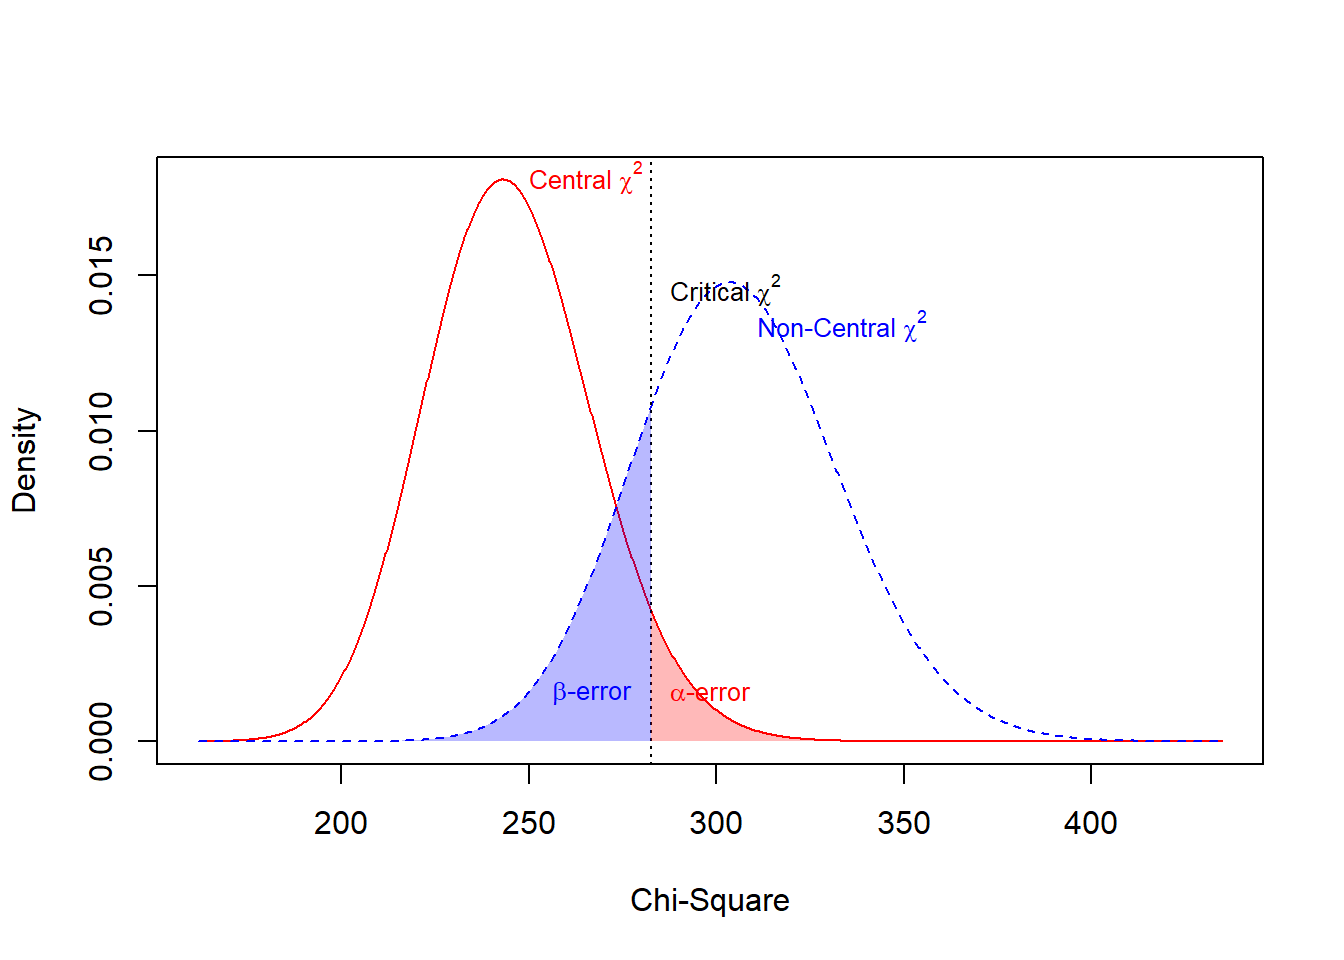

In [ ]:

# A priori power analysis:
# computes the minimum N needed to detect the omission of the three
# cross-loadings in analyzemodel when data arise from h1model.

ap_popmodel <- semPower::semPower.powerLav(
  type       = "a-priori",
  alpha      = ALPHA,
  power      = POWER,
  modelPop   = h1model,
  modelH0    = analyzemodel,
  lavOptions = list(std.lv = TRUE)
)

# Shows effect size, df, required N, critical chi-square,
# noncentrality parameter, and implied alpha/beta results.
summary(ap_popmodel)


## Power curves

Power curves shift the discussion from a single required-$N$ result to a continuous view of how detection probability changes as sample size grows. They are useful for communicating the design in a way that makes trade-offs between $N$, power, and tolerated misspecification immediately visible ([Moshagen & Bader, 2024](#ref-moshagen2024); [Wang, 2023](#ref-wang2023)).

### Model-free approach

The curve below is analytical and model-free: power is a function of RMSEA, $df$, and $\alpha$ only. It answers the planning question of how many observations are needed to detect a fixed degree of global misspecification across a range of possible $N$ values ([Jak et al., 2021](#ref-jak2021); [Jobst et al., 2023](#ref-jobst2023)).

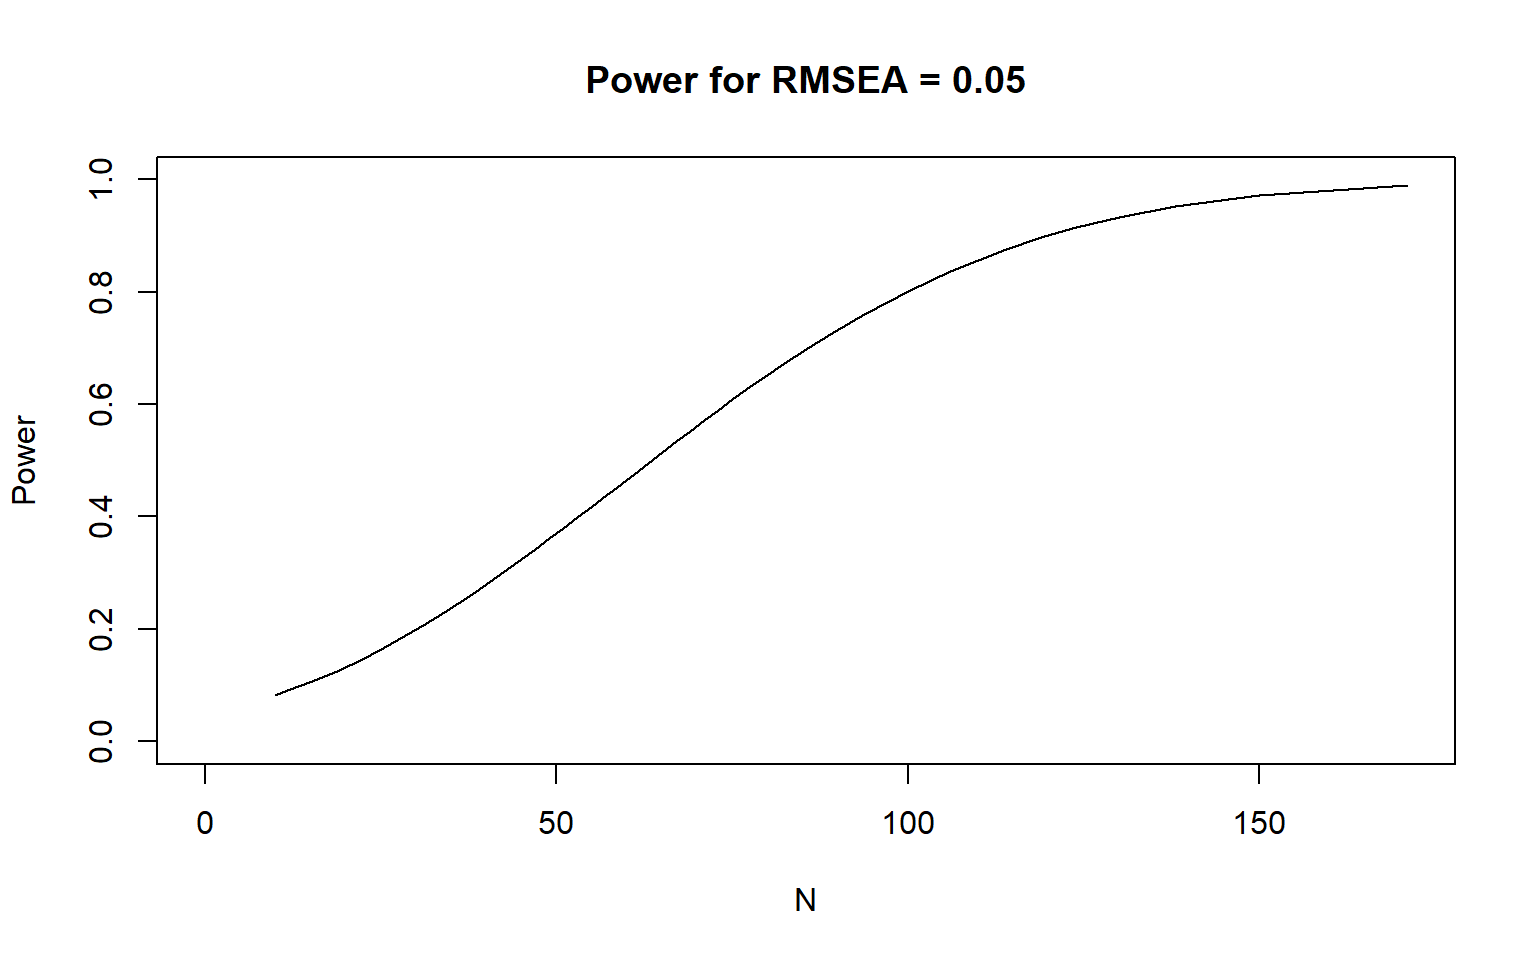

In [ ]:

# Plots statistical power against sample size N.
semPower::semPower.powerPlot.byN(
  effect         = 0.05,      # effect = 0.05 sets the target misfit in RMSEA units.
  effect.measure = "RMSEA",
  alpha          = ALPHA,     # alpha = ALPHA sets the Type I error rate.
  df             = df_model,  # df = df_model sets the model degrees of freedom.
  power.min      = 0.05,
  power.max      = 0.99       # power.min and power.max define the y-axis range of curve.
)


### Model-based approach

This curve traces the same power function for the model-based effect stored in `ap_popmodel`. Because the effect here is derived from the population covariance structure, the curve reflects the specific degree of misspecification implied by the substantive CFA, rather than a generic RMSEA threshold ([Buchberger et al., 2024](#ref-buchberger2024); [Feng & Hancock, 2023](#ref-feng2023)). The sample-size region in which the curve crosses the target power level is the practical read-off from this figure ([Moshagen & Bader, 2024](#ref-moshagen2024)).

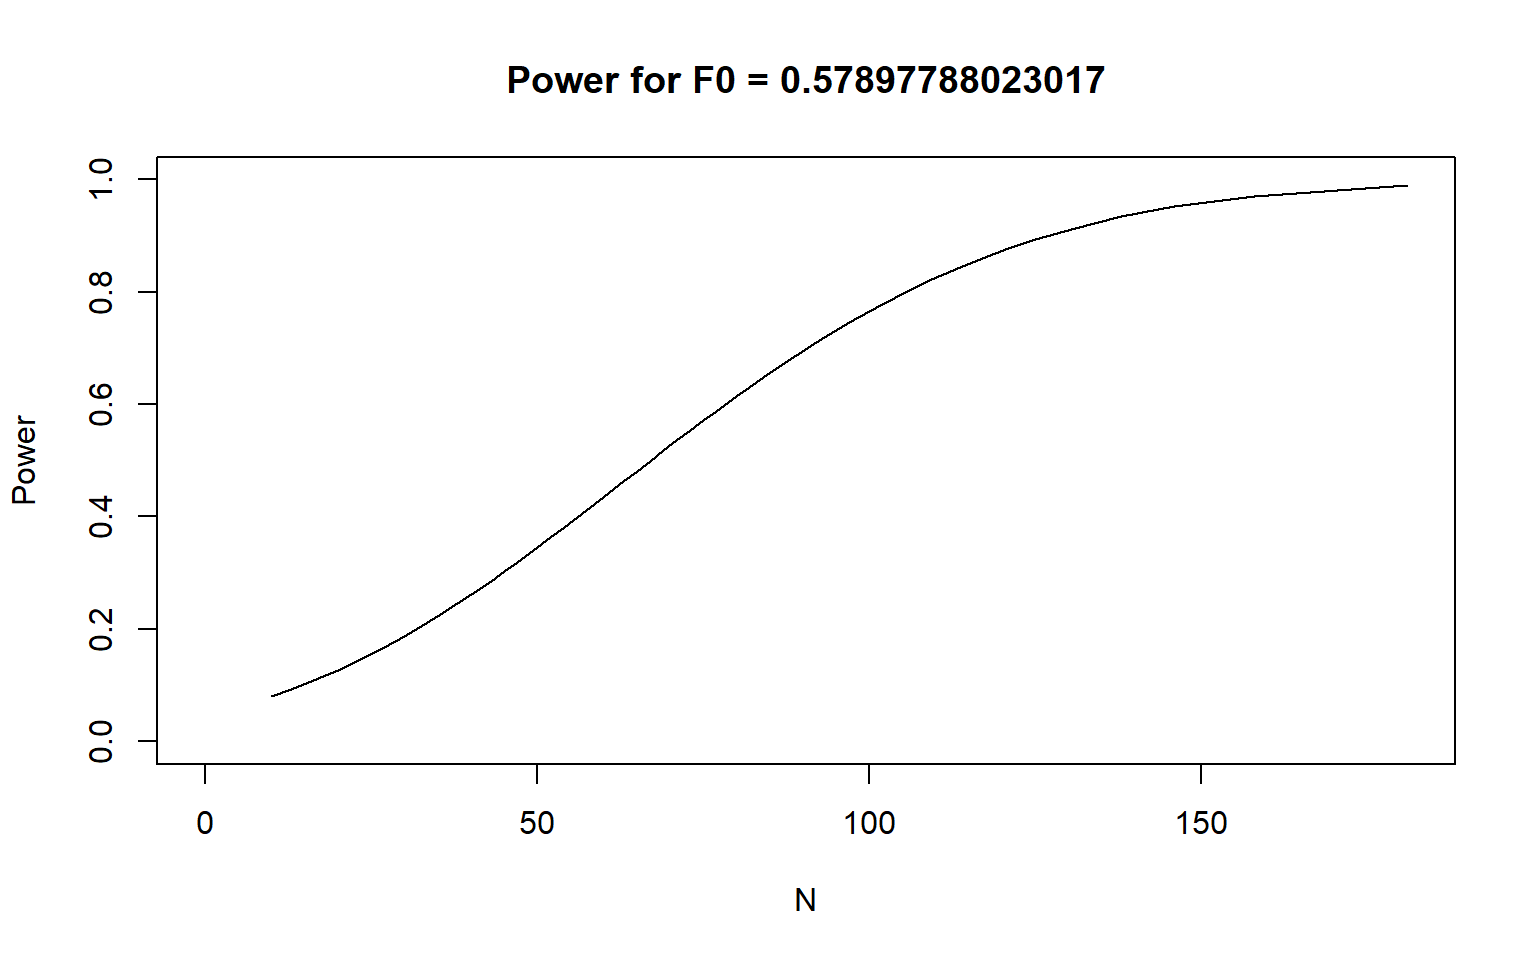

In [ ]:

# Plots the power curve based on the previously computed object `ap_popmodel`.
# x-axis: sample size (N).
# y-axis: statistical power.

semPower.powerPlot(ap_popmodel)


## Summary table

The table below brings the two analytical solutions together, allowing a direct comparison of their sample size requirements under the same $\alpha$ and power targets. The difference between the two estimates reflects a general principle: once the effect is derived from a specific population model rather than from a generic RMSEA convention, the resulting $N$ becomes more substantively grounded and, in this case, more conservative ([Feng & Hancock, 2023](#ref-feng2023); [Wang, 2023](#ref-wang2023)).

In [ ]:

# Helper to safely extract a single numeric value from each result object
safe_num <- function(x) if (length(x) == 0 || is.null(x)) NA else as.numeric(x)[1]

analytical_summary <- data.frame(
    Method = c(
        "Model-free a priori (RMSEA = .05)",
        "Model-based global fit (h1model vs. saturated)"
    ),
    `N Required` = c(
        safe_num(ap_rmsea$requiredN),
        safe_num(ap_popmodel$requiredN)
    ),
    `Power` = c(
        round(safe_num(ap_rmsea$impliedPower), 4),
        round(safe_num(ap_popmodel$impliedPower), 4)
    ),
    `Implied RMSEA` = c(
        round(safe_num(ap_rmsea$rmsea), 4),
        round(safe_num(ap_popmodel$rmsea), 4)
    ),
    df = c(
        safe_num(ap_rmsea$df),
        safe_num(ap_popmodel$df)
    ),
    check.names = FALSE
)

# Render the summary table with simple column alignment for reporting
knitr::kable(analytical_summary, align = "lcccc")


  -----------------------------------------------------------------------------
  Method                                 N Required  Power     Implied     df
                                                                RMSEA     
  -------------------------------------- ---------- -------- ------------ -----
  Model-free a priori (RMSEA = .05)         100      0.8016     0.0500     245

  Model-based global fit (h1model           106      0.8032     0.0486     245
  vs. saturated)                                                          
  -----------------------------------------------------------------------------


Buchberger, E. S., Ngo, C. T., Peikert, A., Brandmaier, A. M., & Werkle-Bergner, M. (2024). Estimating statistical power for structural equation models in developmental cognitive science: A tutorial in R. *Behavior Research Methods*, *56*(7), 1–18. <https://doi.org/10.3758/s13428-024-02396-2>

Feng, Y., & Hancock, G. R. (2023). Power Analysis within a Structural Equation Modeling Framework. In R. H. Hoyle (Ed.), *Handbook of Structural Equation Modeling*. The Guilford Press.

Jak, S., Jorgensen, T. D., Verdam, M. G. E., Oort, F. J., & Elffers, L. (2021). Analytical power calculations for structural equation modeling: A tutorial and Shiny app. *Behavior Research Mehods*, *53*, 1385–1406. <https://doi.org/10.3758/s13428-020-01479-0/Published>

Jobst, L. J., Bader, M., & Moshagen, M. (2023). A tutorial on assessing statistical power and determining sample size for structural equation models. *Psychological Methods*, *28*(1), 207–221. <https://doi.org/10.1037/met0000423>

MacCallum, R. C., Browne, M. W., & Sugawara, H. M. (1996). Power analysis and determination of sample size for covariance structure modeling. *Psychological Methods*, *1*(2), 130–149. <https://doi.org/10.1037/1082-989X.1.2.130>

Moshagen, M., & Bader, M. (2024). <span class="nocase">semPower</span>: General power analysis for structural equation models. *Behavior Research Methods*, *56*(4), 2901–2922. <https://doi.org/10.3758/s13428-023-02254-7>

Wang, Y. A. (2023). *How to Conduct Power Analysis for Structural Equation Models: A Practical Primer* \[Preprint\]. PsyArXiv. <https://doi.org/10.31234/osf.io/4n3uk>